# 📊 Customer Churn Prediction using Machine Learning
This notebook builds a model that predicts whether a telecom customer will **churn** (leave the company) or not, based on their account and service details.

**Workflow covered:**
1. Load & explore the data
2. Clean the data
3. Exploratory Data Analysis (EDA)
4. Encode categorical columns
5. Handle class imbalance with SMOTE
6. Train & compare models (Decision Tree, Random Forest, XGBoost)
7. Evaluate the best model
8. Save the model + encoders
9. **Load the saved model back and predict on a brand-new customer** (the part that was missing)

In [1]:
# ================================
# 📦 IMPORT LIBRARIES
# ================================
import numpy as np                  # ✅ Numerical operations
import pandas as pd                 # ✅ Data handling
import matplotlib.pyplot as plt     # ✅ Plotting (use plt, not ply)
import seaborn as sns               # ✅ Statistical plots

from sklearn.preprocessing import LabelEncoder     # ✅ Encode categorical labels
from imblearn.over_sampling import SMOTE           # ✅ Handle class imbalance
from sklearn.model_selection import train_test_split, cross_val_score  # ✅ Split & cross-validation
from sklearn.tree import DecisionTreeClassifier    # ✅ Decision Tree model
from xgboost import XGBClassifier                  # ✅ XGBoost model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report  # ✅ Evaluation
import pickle                                      # ✅ Save/load model & encoders to disk

## 1️⃣ Load the Dataset

In [2]:
# Load csv file into a pandas DataFrame
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# Quick look at the shape (rows, columns) and the first few records
print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [4]:
# Check data types and non-null counts for every column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Check for missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 2️⃣ Data Cleaning

In [6]:
# customerID is just a unique identifier, it has no predictive value -> drop it
df = df.drop(columns=["customerID"])

In [7]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [8]:
# Look at the unique values of every categorical column
# (helps us spot inconsistent values like blank spaces, typos, etc.)
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
for col in df.columns:
    if col not in numerical_features:
        print(col, df[col].unique())
        print("-" * 50)

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
--------------------------------------------------
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, 

In [9]:
# "TotalCharges" is supposed to be numeric, but some rows contain a blank space " "
# Count how many rows have this problem
len(df[df["TotalCharges"] == ' '])

11

In [10]:
# Replace the blank-space rows with 0.0 (these are new customers with 0 total charges so far)
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"})

In [11]:
# Now convert the column from text (object) to a proper float/numeric type
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [12]:
# Confirm TotalCharges is now numeric (float64)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## 3️⃣ Exploratory Data Analysis (EDA)

In [13]:
# Checking the distribution of the target column "Churn" (Yes/No) -> is the data balanced?
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [14]:
# Summary statistics (mean, std, min, max, etc.) for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Numerical Feature Analysis

In [15]:
# Reusable function to plot a histogram (with mean & median lines) for a numeric column
def plot_histogram(df, column_name):

    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Histogram of {column_name}")

    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    plt.axvline(col_mean, color='red', linestyle='--', label='Mean')
    plt.axvline(col_median, color='green', linestyle='--', label='Median')

    plt.legend()
    plt.show()

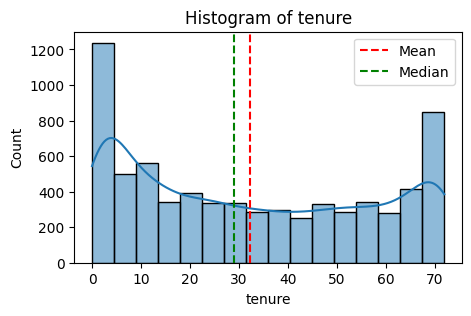

In [16]:
# Distribution of how long customers have stayed (in months)
plot_histogram(df, "tenure")

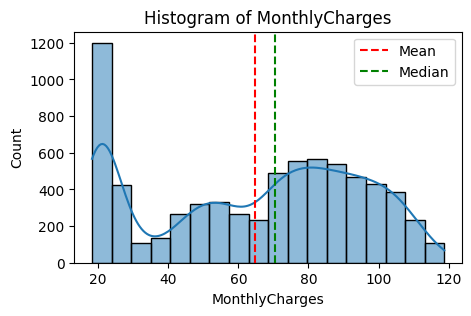

In [17]:
# Distribution of monthly charges
plot_histogram(df, "MonthlyCharges")

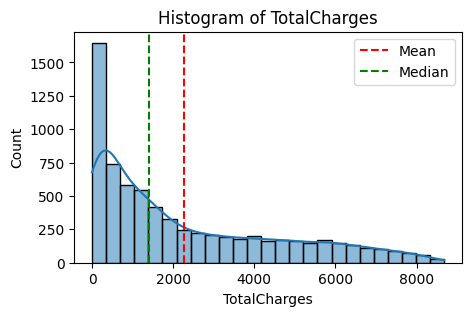

In [18]:
# Distribution of total charges billed so far
plot_histogram(df, "TotalCharges")

### Box Plot for Identifying Outliers

In [19]:
# Reusable function to draw a box plot for a numeric column (helps spot outliers)
def box_plot(df, column_name):

    plt.figure(figsize=(5, 2))
    sns.boxplot(y=df[column_name])
    plt.title(f"Box plot of a {column_name}")
    plt.ylabel(column_name)
    plt.show()

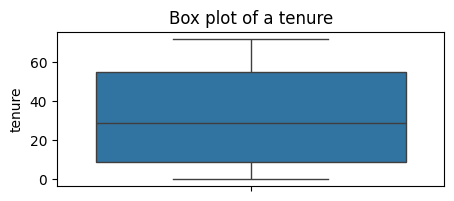

In [20]:
# Outlier check for tenure
box_plot(df, "tenure")

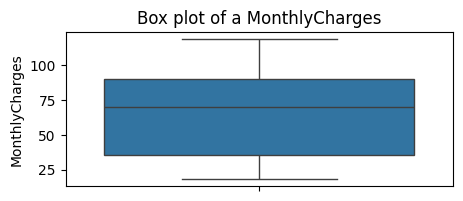

In [21]:
# Outlier check for monthly charges
box_plot(df, "MonthlyCharges")

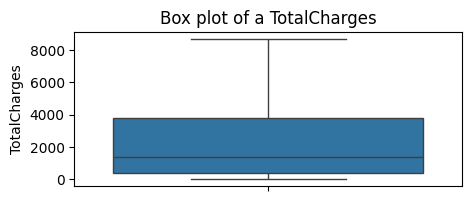

In [22]:
# Outlier check for total charges
box_plot(df, "TotalCharges")

### Correlation Heatmap Matrix

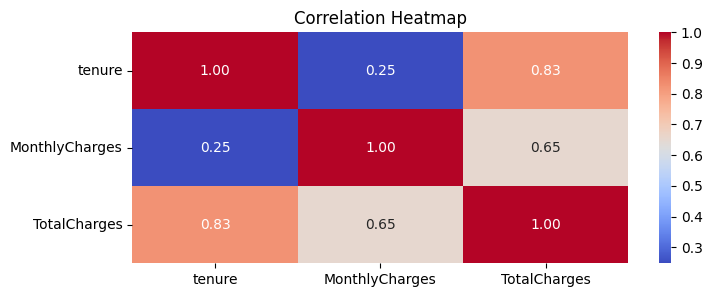

In [23]:
# See how the 3 numerical features relate to one another
plt.figure(figsize=(8, 3))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [24]:
# List all column names remaining in the dataset
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

/tmp/ipykernel_678/1772418187.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_col = df.select_dtypes(include="object").columns.to_list()


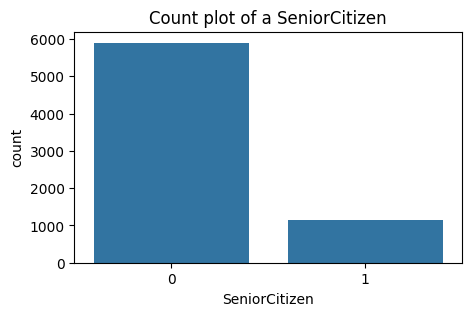

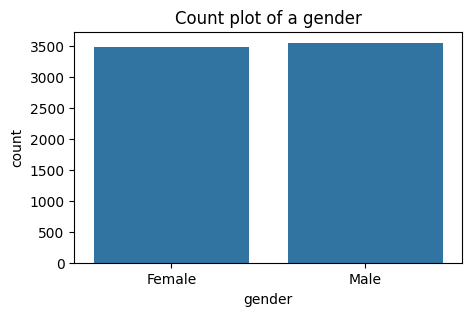

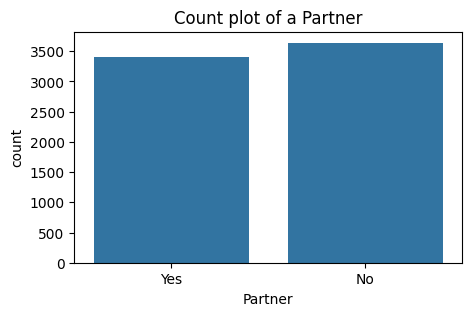

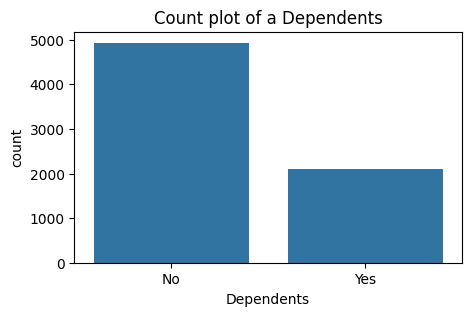

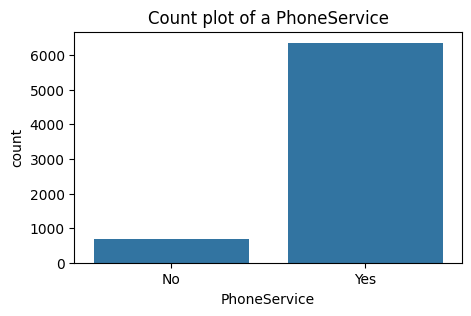

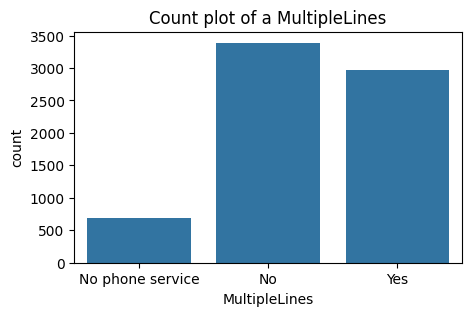

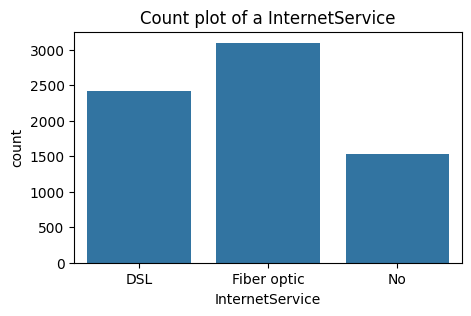

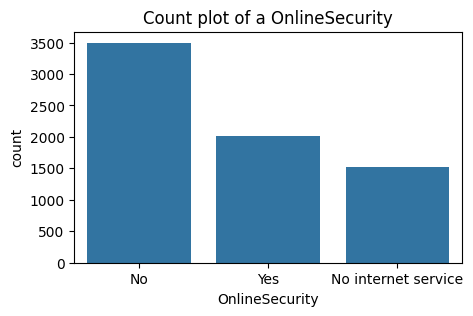

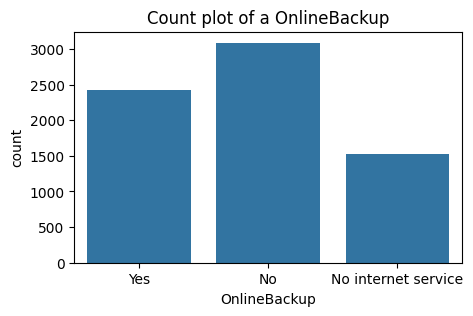

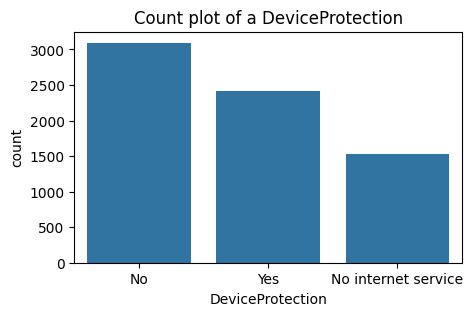

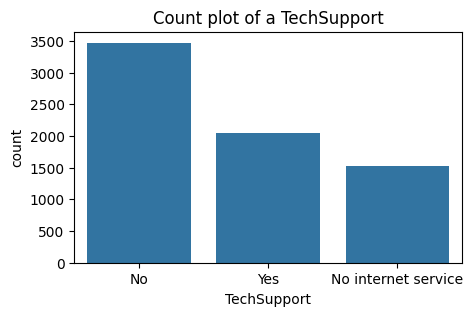

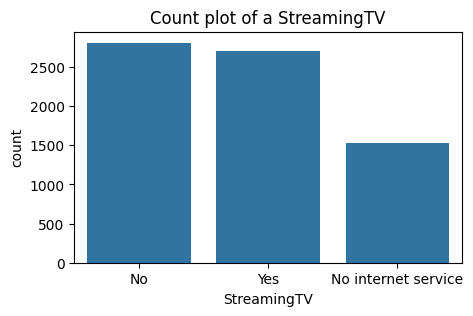

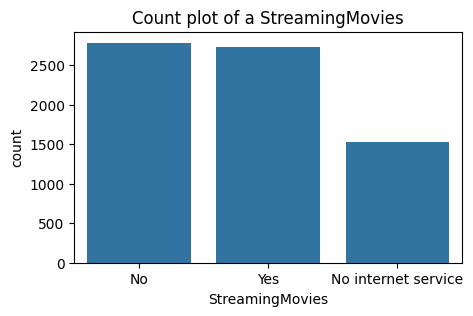

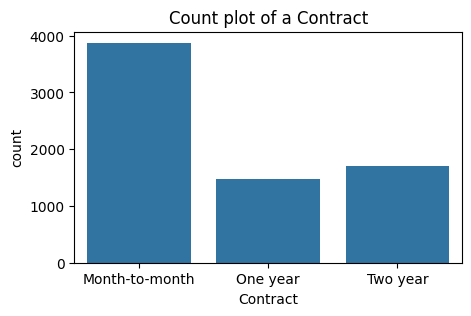

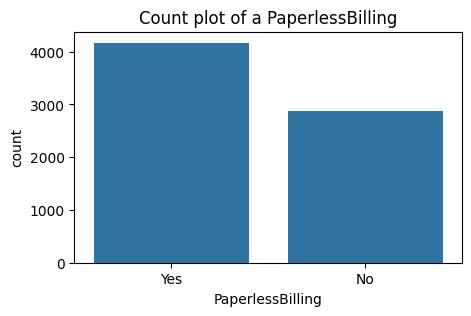

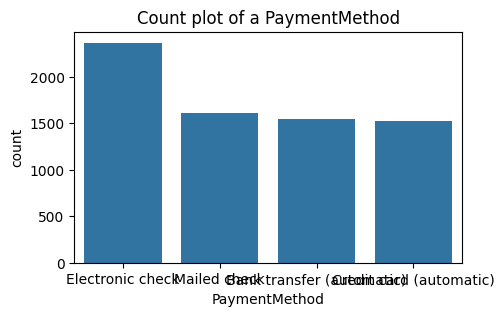

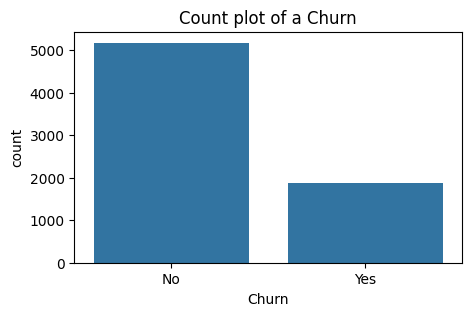

In [25]:
# Count plot for every categorical column (+ SeniorCitizen, which is 0/1 but categorical in nature)
# Shows how many customers fall into each category
object_col = df.select_dtypes(include="object").columns.to_list()
object_col = ["SeniorCitizen"] + object_col

for col in object_col:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Count plot of a {col}")
    plt.show()

## 4️⃣ Encode Categorical Columns
Machine learning models only understand numbers, so every text column needs to be converted into numeric form before training.

In [26]:
# Convert the target column Churn from Yes/No text to 1/0 numbers
# (.astype(int) makes sure it becomes a proper numeric column, not just numbers
# stored as text/object -- otherwise it would accidentally get label-encoded again below)
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0}).astype(int)

In [27]:
# Identify all remaining text (categorical) columns that still need encoding
object_columns = df.select_dtypes(include="object").columns
object_columns

/tmp/ipykernel_678/3468801810.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [28]:
# Use LabelEncoder to turn each categorical column into numbers.
# We keep every column's encoder in a dictionary so we can reuse the SAME encoding
# later when we get a brand-new customer to predict on.
encoders = {}
for col in object_columns:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])
    encoders[col] = label_encoder

# Save the encoders to disk so they can be reloaded later (e.g. in production / a different session)
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [29]:
# Inspect the fitted encoders (one LabelEncoder object per column)
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [30]:
# Confirm the dataframe is now fully numeric
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


## 5️⃣ Train / Test Split

In [31]:
# Separate features (X) from the target (Y = Churn)
X = df.drop(columns=["Churn"])
Y = df["Churn"]

In [32]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [33]:
# Check the class balance in the training set
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


## 6️⃣ Handle Class Imbalance with SMOTE
There are far fewer "Churn = Yes" customers than "Churn = No" customers. SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic examples of the minority class so the model doesn't become biased toward predicting "No Churn" every time.

In [34]:
# Create the SMOTE resampler
smote = SMOTE(random_state=42)

In [35]:
# Apply SMOTE only on the TRAINING data (never on test data, to avoid data leakage)
x_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [36]:
# Check the new shape of the balanced training data
print(y_train_smote.shape)

(8276,)


In [37]:
# Confirm both classes (Churn / No Churn) are now equally represented
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


## 7️⃣ Train & Compare Multiple Models
We try 3 different classifiers and compare their cross-validation accuracy before picking the best one to fine-tune.

In [38]:
# Dictionary of candidate models to compare
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [39]:
# Run 5-fold cross-validation for every model and print the average accuracy
cv_score = {}

for model_name, model in models.items():
    print(f"Trainig {model_name} with default parameters")
    score = cross_val_score(model, x_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_score[model_name] = score
    print(f"{model_name} cross validation accuracy : {np.mean(score):.2f}")
    print("-" * 70)

Trainig Decision Tree with default parameters


Decision Tree cross validation accuracy : 0.78
----------------------------------------------------------------------
Trainig Random Forest with default parameters


Random Forest cross validation accuracy : 0.84
----------------------------------------------------------------------
Trainig XGBoost with default parameters


XGBoost cross validation accuracy : 0.83
----------------------------------------------------------------------


## 8️⃣ Train the Final Model (Random Forest)
Random Forest gave a strong, stable accuracy, so we train it on the full (SMOTE-balanced) training set.

In [40]:
# Train the Random Forest classifier on the balanced training data
rfc = RandomForestClassifier()
rfc.fit(x_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
# Evaluate the trained model on the held-out TEST set (data it has never seen)
x_test_pred = rfc.predict(X_test)

print("Accuracy Score\n", accuracy_score(y_test, x_test_pred))
print("Confusion Matrix\n", confusion_matrix(y_test, x_test_pred))
print("Classification Report\n", classification_report(y_test, x_test_pred))

Accuracy Score
 0.7750177430801988
Confusion Matrix
 [[875 161]
 [156 217]]
Classification Report
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1036
           1       0.57      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



## 9️⃣ Save the Trained Model

In [42]:
# Bundle the trained model together with the feature (column) names it was trained on.
# Saving the feature names too makes sure that any new data we predict on later
# is arranged in exactly the same column order.
model_data = {
    "model": rfc,
    "features_name": X.columns.tolist()
}

with open("customer_churn.pkl", "wb") as f:
    pickle.dump(model_data, f)

## 🔟 Reload the Saved Model (simulating a fresh session / production environment)

In [43]:
# Load the model back from disk exactly as a deployed app would do
with open("customer_churn.pkl", "rb") as f:
    model_data = pickle.load(f)

model = model_data["model"]
feature_names = model_data["features_name"]

In [44]:
# Confirm the model loaded correctly
print(model)

RandomForestClassifier()


In [45]:
# Confirm the feature (column) order the model expects
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 1️⃣1️⃣ Predict on a Brand-New Customer
Now let's simulate a real use case: a NEW customer walks in, and we want to know whether they are likely to churn.

In [46]:
# Example details for one new customer (in raw, human-readable form -- same categories as the original data)
input_data = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85
}

In [47]:
# NOTE: input_data_df still has TEXT values right now (e.g. "Female", "Yes"...).
# The model can only accept numbers, so we CANNOT call model.predict() yet.
# We must first encode it with the saved encoders -> see the next section.
input_data_df = pd.DataFrame([input_data])
input_data_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85


## 1️⃣2️⃣ Final Prediction Pipeline (the missing piece 👇)
This is the part that completes the notebook: reload the saved model, encode the new customer's categorical fields using the saved encoders, then predict Churn / No Churn along with the probability.

In [48]:
# ================================================
# 🔁 RELOAD THE TRAINED MODEL (as "loaded_model")
# ================================================
# In a real deployment, this would be a fresh script/session that only
# has access to the saved .pkl files -- not the original `rfc` variable.
with open("customer_churn.pkl", "rb") as f:
    model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_name"]

In [49]:
# ================================================
# 🧾 REBUILD THE NEW CUSTOMER RECORD
# ================================================
input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

# ------------------------------------------------
# 🔠 Encode categorical features using the saved encoders
# ------------------------------------------------
# Every column that was label-encoded during training must go through
# the SAME encoder here, otherwise the numbers won't mean the same thing.
for column, encoder in encoders.items():
    input_data_df[column] = encoder.transform(input_data_df[column])

# Make sure the new customer's columns are in the exact order the model expects
input_data_df = input_data_df[feature_names]

# ------------------------------------------------
# 🔮 Make a prediction
# ------------------------------------------------
prediction = loaded_model.predict(input_data_df)          # 1 = Churn, 0 = No Churn
pred_prob = loaded_model.predict_proba(input_data_df)      # [P(No Churn), P(Churn)]

print(prediction)

# ------------------------------------------------
# 📢 Show a human-friendly result
# ------------------------------------------------
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediction Probability: {pred_prob}")

[0]
Prediction: No Churn
Prediction Probability: [[0.71 0.29]]


### ✅ Result
The model predicts **No Churn** for this customer, with roughly a 22% probability of churning and 78% probability of staying — meaning the customer is more likely to remain with the company. You can change any value inside `input_data` above and re-run this cell to test other customers.